🤖 Machine Learning &nbsp;·&nbsp; *Bài 12/23*

[« Machine Learning - Scale](011_ml_scale.ipynb) &nbsp;•&nbsp; [📚 Mục lục](../README.md) &nbsp;•&nbsp; [Machine Learning - Decision Tree »](013_ml_decision_tree.ipynb)

# Machine Learning - Train/Test

> 📖 **Học song song trên W3Schools:** [python_ml_train_test.asp](https://www.w3schools.com/python/python_ml_train_test.asp)
>
> 🎯 **Trong bài này:** Evaluate Your Model · What is Train/Test · Start With a Data Set · Split Into Train/Test · Display the Training Set · Display the Testing Set · Fit the Data Set · R2 · Bring in the Testing Set · Predict Values · ➕ Mở rộng: train_test_split của scikit-learn

## Evaluate Your Model — Đánh giá mô hình

Trong học máy, ta tạo mô hình để **dự đoán** kết quả của một số sự kiện — như ở bài trước khi dự đoán CO2 của xe từ trọng lượng và dung tích.

Để đo mô hình **đủ tốt** hay chưa, dùng phương pháp **Train/Test**.

## What is Train/Test — Train/Test là gì?

Train/Test là phương pháp đo **độ chính xác** của mô hình.

Gọi là Train/Test vì ta **chia** tập dữ liệu làm hai: tập **huấn luyện (training)** và tập **kiểm tra (testing)**:

- **80%** để huấn luyện, **20%** để kiểm tra.
- **Huấn luyện** mô hình bằng tập training — tức là *tạo* mô hình.
- **Kiểm tra** mô hình bằng tập testing — tức là *đánh giá độ chính xác*.

## Start With a Data Set — Bắt đầu với tập dữ liệu

Tập dữ liệu minh hoạ **100 khách hàng** của một cửa hàng và thói quen mua sắm: trục x là số **phút** trước khi mua, trục y là **số tiền** đã chi:

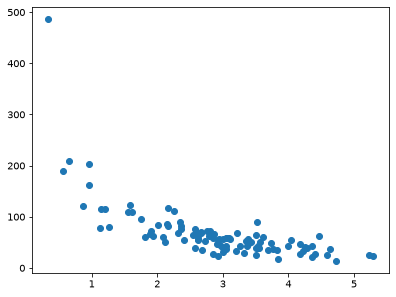

In [1]:
import numpy
import matplotlib.pyplot as plt

numpy.random.seed(2)

x = numpy.random.normal(3, 1, 100)
y = numpy.random.normal(150, 40, 100) / x

plt.scatter(x, y)
plt.show()

## Split Into Train/Test — Chia train/test

Tập training là **80% ngẫu nhiên** của dữ liệu gốc. Tập testing là 20% còn lại:

In [2]:
train_x = x[:80]
train_y = y[:80]

test_x = x[80:]
test_y = y[80:]

## Display the Training Set — Hiển thị tập training

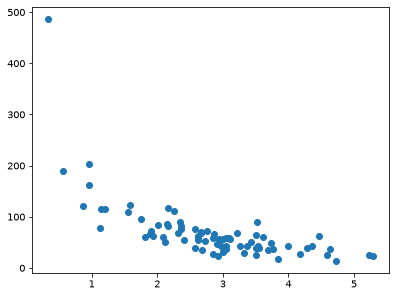

In [3]:
plt.scatter(train_x, train_y)
plt.show()

Trông giống tập gốc → có vẻ là lựa chọn hợp lý.

## Display the Testing Set — Hiển thị tập testing

Để chắc chắn tập testing không hoàn toàn khác biệt:

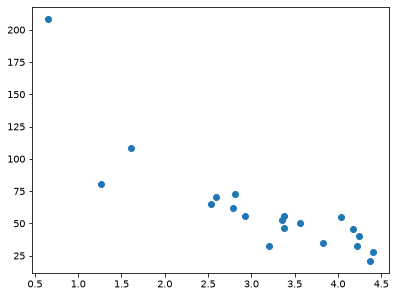

In [4]:
plt.scatter(test_x, test_y)
plt.show()

## Fit the Data Set — Khớp mô hình

Dữ liệu trông như phù hợp với **hồi quy đa thức**. Vẽ đường hồi quy đa thức bậc 4:

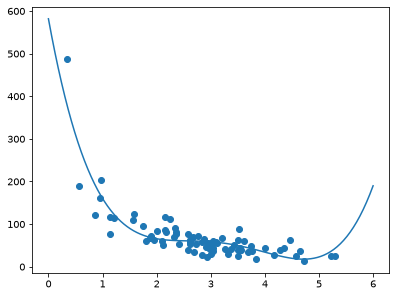

In [5]:
mymodel = numpy.poly1d(numpy.polyfit(train_x, train_y, 4))

myline = numpy.linspace(0, 6, 100)

plt.scatter(train_x, train_y)
plt.plot(myline, mymodel(myline))
plt.show()

Kết quả hỗ trợ đề xuất dùng hồi quy đa thức, dù có thể cho kết quả lạ nếu dự đoán ngoài phạm vi dữ liệu — ví dụ đường cong gợi ý một khách hàng ở 6 phút sẽ chi rất nhiều tiền, có thể là dấu hiệu **overfitting (quá khớp)**.

## R2

Còn nhớ **R2 (R-squared)**? Nó đo mức độ quan hệ giữa x và y, từ 0 (không quan hệ) đến 1 (quan hệ hoàn toàn).

Đo R2 trên tập **training**:

In [6]:
from sklearn.metrics import r2_score

r2 = r2_score(train_y, mymodel(train_x))

print(r2)

0.7988645544629797


> 📌 Kết quả 0.799 cho thấy quan hệ **ổn**.

## Bring in the Testing Set — Kiểm tra bằng tập testing

Giờ đã có mô hình ổn — ít nhất là với tập training. Hãy xem nó có cho kết quả tương tự với tập **testing** không:

In [7]:
r2 = r2_score(test_y, mymodel(test_x))

print(r2)

0.8086921460343581


> 📌 Kết quả 0.809 cho thấy mô hình **cũng phù hợp** với tập testing → tự tin dùng mô hình để dự đoán.

## Predict Values — Dự đoán

Một khách hàng ở trong cửa hàng **5 phút** sẽ chi bao nhiêu tiền?

In [8]:
print(mymodel(5))

22.87962591811811


Dự đoán khách hàng chi khoảng **22.88** đô la — khớp với đồ thị.

## ➕ Mở rộng: train_test_split của scikit-learn

Thực tế, ta dùng `train_test_split` để chia **ngẫu nhiên**:

In [9]:
from sklearn.model_selection import train_test_split

train_x2, test_x2, train_y2, test_y2 = train_test_split(x, y, test_size=0.2, random_state=0)
print(len(train_x2), len(test_x2))

80 20


---

## 🧠 Ghi nhớ nhanh

> - Chia dữ liệu **80% train / 20% test**: huấn luyện trên train, đánh giá trên test.
> - R² trên train **và** test đều tốt → mô hình đáng tin; chỉ tốt trên train → **overfitting**.
> - `train_test_split(X, y, test_size=0.2)` để chia ngẫu nhiên.

---

## 📝 Exercise — Bài tập nhanh

**❓ Câu hỏi:** Tỉ lệ chia train/test phổ biến trong bài là bao nhiêu?

- **A.** 95% / 5%
- **B.** 50% / 50%
- **C.** 20% / 80%
- **D.** 80% / 20%

<details>
<summary>👉 Xem đáp án</summary>

✅ **Đáp án: D** — 80% / 20%

</details>

---

[« Machine Learning - Scale](011_ml_scale.ipynb) &nbsp;•&nbsp; [📚 Mục lục](../README.md) &nbsp;•&nbsp; [Machine Learning - Decision Tree »](013_ml_decision_tree.ipynb)